✅ 2D Asset kaydedildi: ../../../assets/51_lln_2d.png


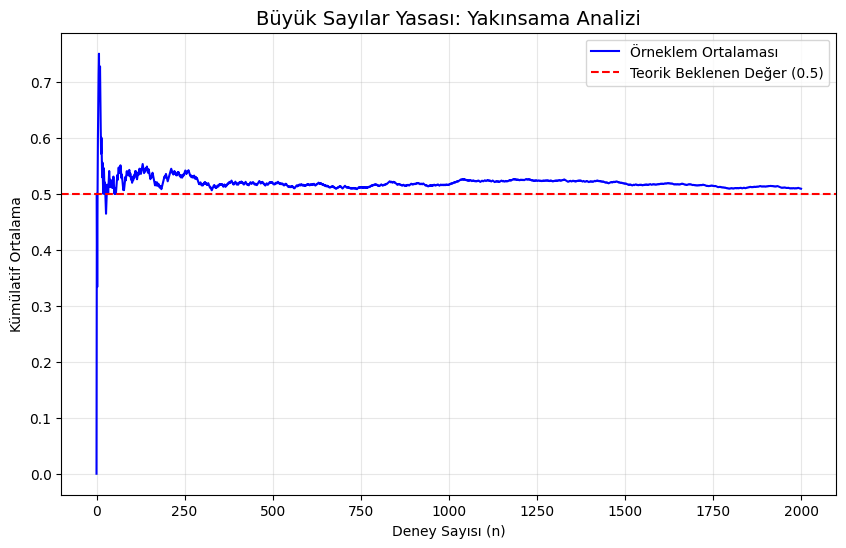

✅ 3D Asset kaydedildi: ../../../assets/51_lln_3d.png


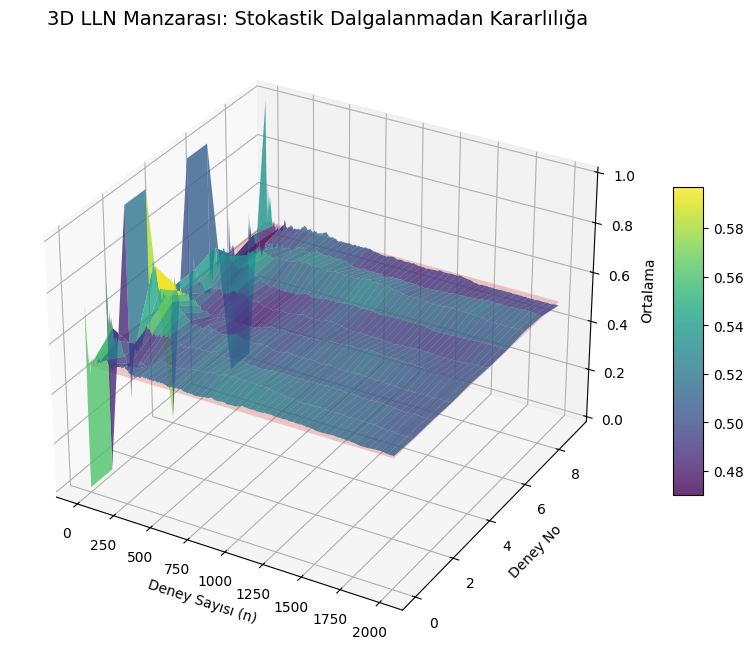

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

def run_lln_master():
    # --- PROFESYONEL YOL AYARI (Relative Path) ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Deney Parametreleri
    n_trials = 2000
    n_experiments = 10 # 3D için birden fazla deney
    expected_value = 0.5 # Adil bir madeni para için

    # 2. Veri Üretimi
    # Her sütun ayrı bir deneyi temsil eder
    results = np.random.randint(0, 2, size=(n_trials, n_experiments))
    cumulative_averages = np.cumsum(results, axis=0) / np.arange(1, n_trials + 1)[:, None]

    # --- 📸 ASSET 1: 2D CONVERGENCE (51_lln_2d.png) ---
    fig1 = plt.figure(figsize=(10, 6))
    plt.plot(cumulative_averages[:, 0], color='blue', lw=1.5, label='Örneklem Ortalaması')
    plt.axhline(y=expected_value, color='red', linestyle='--', label=f'Teorik Beklenen Değer ({expected_value})')
    plt.title("Büyük Sayılar Yasası: Yakınsama Analizi", fontsize=14)
    plt.xlabel("Deney Sayısı (n)"); plt.ylabel("Kümülatif Ortalama")
    plt.grid(alpha=0.3); plt.legend()
    
    plt.savefig(os.path.join(asset_path, '51_lln_2d.png'), dpi=300)
    print(f"✅ 2D Asset kaydedildi: {asset_path}/51_lln_2d.png")
    plt.show()

    # --- 📸 ASSET 2: 3D STABILITY LANDSCAPE (51_lln_3d.png) ---
    fig2 = plt.figure(figsize=(12, 8))
    ax3d = fig2.add_subplot(111, projection='3d')
    
    X = np.arange(1, n_trials + 1)
    Y = np.arange(n_experiments)
    X_mesh, Y_mesh = np.meshgrid(X, Y)
    Z = cumulative_averages.T # Deneyleri yüzey olarak çiziyoruz

    surf = ax3d.plot_surface(X_mesh, Y_mesh, Z, cmap='viridis', alpha=0.8, edgecolor='none')
    
    # Beklenen değer düzlemini çizelim
    ax3d.plot_surface(X_mesh, Y_mesh, np.full_like(Z, expected_value), 
                      color='red', alpha=0.2, label='Teorik Limit')

    ax3d.set_title("3D LLN Manzarası: Stokastik Dalgalanmadan Kararlılığa", fontsize=14)
    ax3d.set_xlabel('Deney Sayısı (n)'); ax3d.set_ylabel('Deney No'); ax3d.set_zlabel('Ortalama')
    fig2.colorbar(surf, ax=ax3d, shrink=0.5, aspect=10)
    
    plt.savefig(os.path.join(asset_path, '51_lln_3d.png'), dpi=300)
    print(f"✅ 3D Asset kaydedildi: {asset_path}/51_lln_3d.png")
    plt.show()

if __name__ == "__main__":
    run_lln_master()